# Computer Vision — Complex Computing Problem
## Human Activity Recognition via Pose Estimation

**Name:** Faaiz Ahmed
**Roll No:** 23-AI-40
**Course:** AI-3206 Computer Vision  
**Batch:** 2023 Fall

---

### Learning Objective 
To enable students to utilize a pre-trained pose estimation model, analyze human body keypoints, compute joint angles, and design a rule-based system to classify human activities. 

### Scenario 
You are required to design a pipeline that detects human poses, analyzes joint geometry, and classifies activities 
being performed. For your video source, you may use any one of the following options: 
- **Webcam:** Record yourself or someone else performing two or more distinct activities (e.g., standing, sitting, raising arms, squatting). 
- **Online Video:** Download any suitable clip from YouTube or any other platform that clearly shows a 
person performing distinct activities. 
- **Pre-recorded Clip:** Use any existing video file you already have. 
**Note:** The video should contain at least two distinct activities and the person should be clearly visible throughout.

### Tasks 
1.  **Pose Detection & Pre-processing**
- Use a pre-trained model (e.g., MediaPipe Pose or OpenPose) to extract body keypoints from each frame. 
- Apply a smoothing filter on the keypoint coordinates across frames to reduce jitter in the detections. 
- Visualize the skeleton overlay on the original frames. 
2.  **Joint Angle Computation & Tracking** 
- Select at least three meaningful joint angles (e.g., knee angle, elbow angle, hip angle) and compute them using the detected keypoints across all frames. 
- Plot how these angles change over time and identify the frames where a transition between activities occurs. 
3.  **Rule-Based Activity Classification** 
- Design a rule-based classifier using joint angle thresholds to distinguish between at least two activities. 
* Report the classification result per frame and calculate the overall accuracy against your own manually labeled ground truth.

---

### Pipeline Overview
1. **Pose Detection & Pre-processing** — MediaPipe Pose + coordinate smoothing + skeleton overlay  
2. **Joint Angle Computation & Tracking** — Knee, elbow, hip angles over time + transition detection  
3. **Rule-Based Activity Classification** — Threshold logic for 4 activities + accuracy vs ground truth

### Video Source
```
Video file : video1.mp4  (download from: https://www.pexels.com/video/a-woman-doing-a-squat-exercise-7690495/)
Activities : Standing | Sitting | Squatting | Arm Raised
```

> **How to get a suitable video:**  
> Option A — Record yourself performing each activity for ~10 seconds each.  
> Option B — Download a YouTube fitness/yoga clip:  
> `yt-dlp -f mp4 -o video1.mp4 "<YouTube URL>"`

---

In [1]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from collections import deque
import os
import warnings
warnings.filterwarnings('ignore')

print(f"OpenCV  : {cv2.__version__}")
print(f"MediaPipe: {mp.__version__}")
print(f"NumPy   : {np.__version__}")

OpenCV  : 4.9.0
MediaPipe: 0.10.14
NumPy   : 1.26.4


## Task 1 — Pose Detection & Pre-processing

In [2]:
mp_pose=mp.solutions.pose
mp_drawing=mp.solutions.drawing_utils
mp_styles=mp.solutions.drawing_styles
pose_model = mp_pose.Pose(
    static_image_mode = False,   # video mode: tracks landmarks across frames
    model_complexity = 1,       # 0=Lite, 1=Full, 2=Heavy
    smooth_landmarks= True,    # internal temporal smoothing (extra layer)
    min_detection_confidence= 0.5,
    min_tracking_confidence = 0.5
)

def get_landmark_px(landmarks,landmark_enum, w, h):
    lm = landmarks[landmark_enum.value]
    return [lm.x * w, lm.y * h]

print("MediaPipe Pose initialised successfully.")

MediaPipe Pose initialised successfully.


In [3]:
SMOOTH_WINDOW = 5  
def make_smoother():
    return deque(maxlen=SMOOTH_WINDOW)
def smooth(history: deque, new_value: float) -> float:
    history.append(new_value)
    return float(np.mean(history))
print(f"Smoothing window = {SMOOTH_WINDOW} frames")

Smoothing window = 5 frames


## Task 2 — Joint Angle Computation

#### Angle Formula

$$\theta = \left|\arctan2(C_y - B_y,\; C_x - B_x) - \arctan2(A_y - B_y,\; A_x - B_x)\right| \times \frac{180}{\pi}$$

If the result exceeds 180°, we subtract from 360° to keep the angle in \[0°, 180°\].  
This mirrors the convention used in clinical goniometry.

In [4]:
def calculate_angle(a:list,b:list,c:list)->float:
    a, b, c = np.array(a), np.array(b), np.array(c)
    angle = np.abs(
        np.degrees(
            np.arctan2(c[1]-b[1], c[0]-b[0]) -
            np.arctan2(a[1]-b[1], a[0]-b[0])
        )
    )
    return 360.0 - angle if angle > 180.0 else angle

assert abs(calculate_angle([0,1],[0,0],[1,0]) - 90.0) < 1e-6, "Unit test failed"
assert abs(calculate_angle([0,1],[0,0],[0,-1]) - 180.0) < 1e-6, "Unit test failed"
print("calculate_angle() passed unit tests.")

calculate_angle() passed unit tests.


## Task 3 — Rule-Based Activity Classifier

### Classification Logic

| Activity     | Knee angle | Hip angle  | Elbow angle |
|:-------------|:----------:|:----------:|:-----------:|
| Squatting    | < 100°     | any        | any         |
| Sitting      | 100–150°   | < 90°      | any         |
| Arm Raised   | > 150°     | any        | < 70°       |
| Standing     | > 150°     | ≥ 90°      | ≥ 70°       |

In [5]:
SQUAT_KNEE_MAX = 100   
SIT_KNEE_MAX = 150   
SIT_HIP_MAX = 90    
ARM_ELBOW_MAX = 70   

ACTIVITY_COLORS = {
    "Squatting" : (0, 165, 255),   
    "Sitting"   : (255, 0, 0),   
    "Arm Raised": (0, 255, 255),   
    "Standing"  : (0, 255, 0),     
    "Unknown"   : (128, 128, 128), 
}

def classify_activity(knee_angle: float,hip_angle:  float,elbow_angle: float) -> str:
    if knee_angle < SQUAT_KNEE_MAX:
        return "Squatting"
    elif knee_angle < SIT_KNEE_MAX and hip_angle < SIT_HIP_MAX:
        return "Sitting"
    elif elbow_angle < ARM_ELBOW_MAX:
        return "Arm Raised"
    else:
        return "Standing"
assert classify_activity(80,  60, 120) == "Squatting",  "Rule error"
assert classify_activity(130, 80, 120) == "Sitting",    "Rule error"
assert classify_activity(170, 95,  50) == "Arm Raised", "Rule error"
assert classify_activity(170, 95, 120) == "Standing",   "Rule error"
print("classify_activity() passed all sanity checks.")

classify_activity() passed all sanity checks.


## Main Processing Loop

This cell:
1. Reads the video frame-by-frame  
2. Runs MediaPipe Pose on every frame  
3. Smooths 6 landmark coordinates (hip, knee, ankle, shoulder, elbow, wrist) via moving average  
4. Computes three joint angles  
5. Classifies the current activity  
6. Draws skeleton + annotation overlay  
7. Writes the annotated frame to `output_annotated.mp4`  
8. Stores all per-frame data for later analysis

In [6]:
VIDEO_IN  = "video1.mp4"         
VIDEO_OUT = "output_annotated.mp4"
DISPLAY=True                 
frame_numbers = []
knee_angles_raw = []
elbow_angles_raw= []
hip_angles_raw= []
knee_angles_sm = []
elbow_angles_sm = []
hip_angles_sm = []
predictions = []
sample_frames = []   
smoothers = {key: make_smoother() for key in [
    'hip_x','hip_y','knee_x','knee_y','ankle_x','ankle_y',
    'shoulder_x','shoulder_y','elbow_x','elbow_y','wrist_x','wrist_y'
]}

cap = cv2.VideoCapture(VIDEO_IN)
if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {VIDEO_IN}")

frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
total_fr = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Video: {VIDEO_IN}")
print(f"Size : {frame_w} × {frame_h}   FPS: {fps:.1f}   Frames: {total_fr}")

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(VIDEO_OUT, fourcc, fps, (frame_w, frame_h))
frame_count = 0
SAMPLE_EVERY = max(1, total_fr // 6)  

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = pose_model.process(rgb)
    annotated = frame.copy()
    try:
        if result.pose_landmarks is None:
            raise AttributeError 
        lm = result.pose_landmarks.landmark
        hip_r = get_landmark_px(lm, mp_pose.PoseLandmark.LEFT_HIP,frame_w, frame_h)
        knee_r = get_landmark_px(lm, mp_pose.PoseLandmark.LEFT_KNEE, frame_w, frame_h)
        ankle_r = get_landmark_px(lm, mp_pose.PoseLandmark.LEFT_ANKLE,frame_w, frame_h)
        shoulder_r= get_landmark_px(lm, mp_pose.PoseLandmark.LEFT_SHOULDER, frame_w, frame_h)
        elbow_r = get_landmark_px(lm, mp_pose.PoseLandmark.LEFT_ELBOW,frame_w, frame_h)
        wrist_r = get_landmark_px(lm, mp_pose.PoseLandmark.LEFT_WRIST,frame_w, frame_h)

        hip = [smooth(smoothers['hip_x'], hip_r[0]),smooth(smoothers['hip_y'],hip_r[1])]
        knee = [smooth(smoothers['knee_x'], knee_r[0]),smooth(smoothers['knee_y'],knee_r[1])]
        ankle = [smooth(smoothers['ankle_x'], ankle_r[0]),smooth(smoothers['ankle_y'],ankle_r[1])]
        shoulder = [smooth(smoothers['shoulder_x'], shoulder_r[0]),smooth(smoothers['shoulder_y'], shoulder_r[1])]
        elbow= [smooth(smoothers['elbow_x'],elbow_r[0]),smooth(smoothers['elbow_y'],elbow_r[1])]
        wrist= [smooth(smoothers['wrist_x'],wrist_r[0]),smooth(smoothers['wrist_y'],wrist_r[1])]
        knee_raw = calculate_angle(hip_r,knee_r, ankle_r)
        elbow_raw = calculate_angle(shoulder_r, elbow_r, wrist_r)
        hip_raw = calculate_angle(shoulder_r, hip_r, knee_r)

        knee_sm = calculate_angle(hip, knee, ankle)
        elbow_sm = calculate_angle(shoulder, elbow, wrist)
        hip_sm = calculate_angle(shoulder, hip,knee)
        activity = classify_activity(knee_sm, hip_sm, elbow_sm)
        color = ACTIVITY_COLORS[activity]
        frame_numbers.append(frame_count)
        knee_angles_raw.append(knee_raw)
        elbow_angles_raw.append(elbow_raw)
        hip_angles_raw.append(hip_raw)
        knee_angles_sm.append(knee_sm)
        elbow_angles_sm.append(elbow_sm)
        hip_angles_sm.append(hip_sm)
        predictions.append(activity)

        mp_drawing.draw_landmarks(
            annotated,
            result.pose_landmarks,
            mp_pose.POSE_CONNECTIONS,
            landmark_drawing_spec=mp_drawing.DrawingSpec(
                color=(245,117,66), thickness=3, circle_radius=3),
            connection_drawing_spec=mp_drawing.DrawingSpec(
                color=(245,66,230), thickness=3)
        )

        cv2.putText(annotated, f"Knee : {knee_sm:.0f}deg",
                    (10, 40),  cv2.FONT_HERSHEY_SIMPLEX,2, (255,255,255), 2, cv2.LINE_AA)
        cv2.putText(annotated, f"Hip  : {hip_sm:.0f}deg",
                    (10, 100),  cv2.FONT_HERSHEY_SIMPLEX, 2, (255,255,255), 2, cv2.LINE_AA)
        cv2.putText(annotated, f"Elbow: {elbow_sm:.0f}deg",
                    (10, 150), cv2.FONT_HERSHEY_SIMPLEX, 2, (255,255,255), 2, cv2.LINE_AA)

        cv2.rectangle(annotated, (0, frame_h-60), (frame_w, frame_h), (0,0,0), -1)
        cv2.putText(annotated, activity,
                    (10, frame_h-15), cv2.FONT_HERSHEY_SIMPLEX,
                    1.4, color, 3, cv2.LINE_AA)

        cv2.putText(annotated, f"Frame {frame_count}",
                    (frame_w-160, 30), cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (200,200,200), 1)

    except AttributeError:
        predictions.append("Unknown")
        frame_numbers.append(frame_count)
        knee_angles_raw.append(np.nan)
        elbow_angles_raw.append(np.nan)
        hip_angles_raw.append(np.nan)
        knee_angles_sm.append(np.nan)
        elbow_angles_sm.append(np.nan)
        hip_angles_sm.append(np.nan)

    if frame_count % SAMPLE_EVERY == 0:
        sample_frames.append((frame_count, annotated.copy()))
    writer.write(annotated)

    if DISPLAY:
        disp = cv2.resize(annotated, (900, int(900 * frame_h / frame_w)))
        cv2.imshow("Human Activity Recognition — press Q to quit", disp)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    frame_count += 1

cap.release()
writer.release()
cv2.destroyAllWindows()
print(f"\nProcessed {frame_count} frames.")
print(f"Annotated video saved → {VIDEO_OUT}")

Video: video1.mp4
Size : 4096 × 2160   FPS: 25.0   Frames: 360

Processed 360 frames.
Annotated video saved → output_annotated.mp4


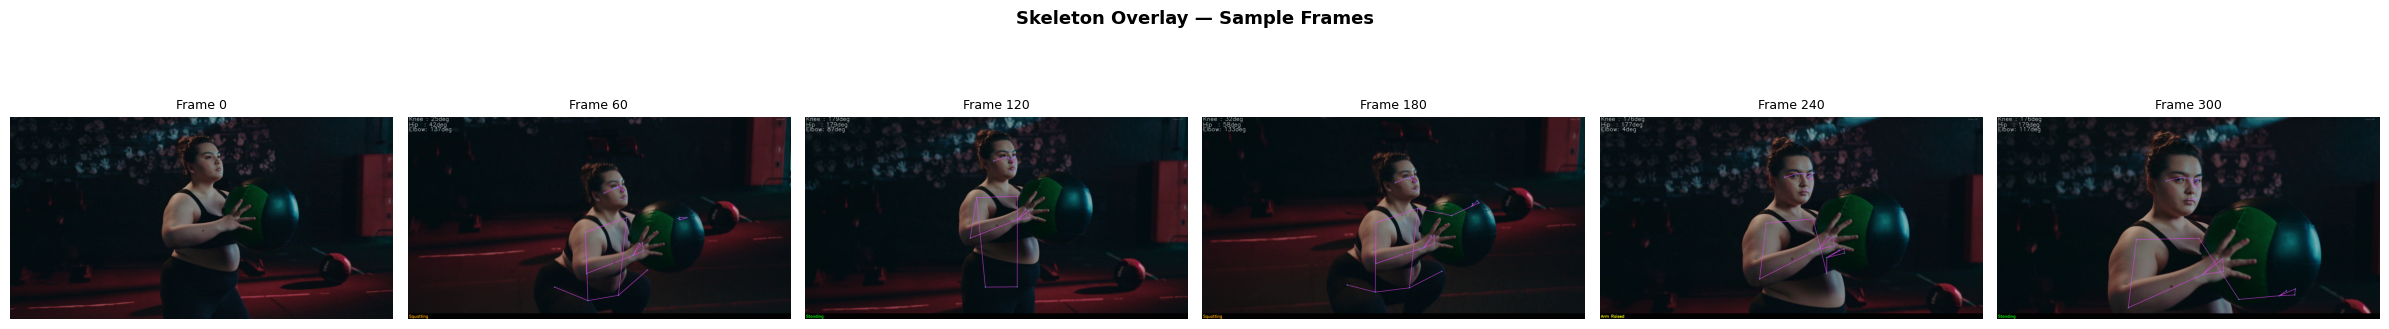

Saved: sample_frames_skeleton.png


In [7]:
if sample_frames:
    n = len(sample_frames)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for ax, (fnum, frm) in zip(axes, sample_frames):
        ax.imshow(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Frame {fnum}", fontsize=9)
        ax.axis('off')
    fig.suptitle("Skeleton Overlay — Sample Frames", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("sample_frames_skeleton.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("Saved: sample_frames_skeleton.png")
else:
    print("No sample frames captured — check that the video file exists and ran correctly.")

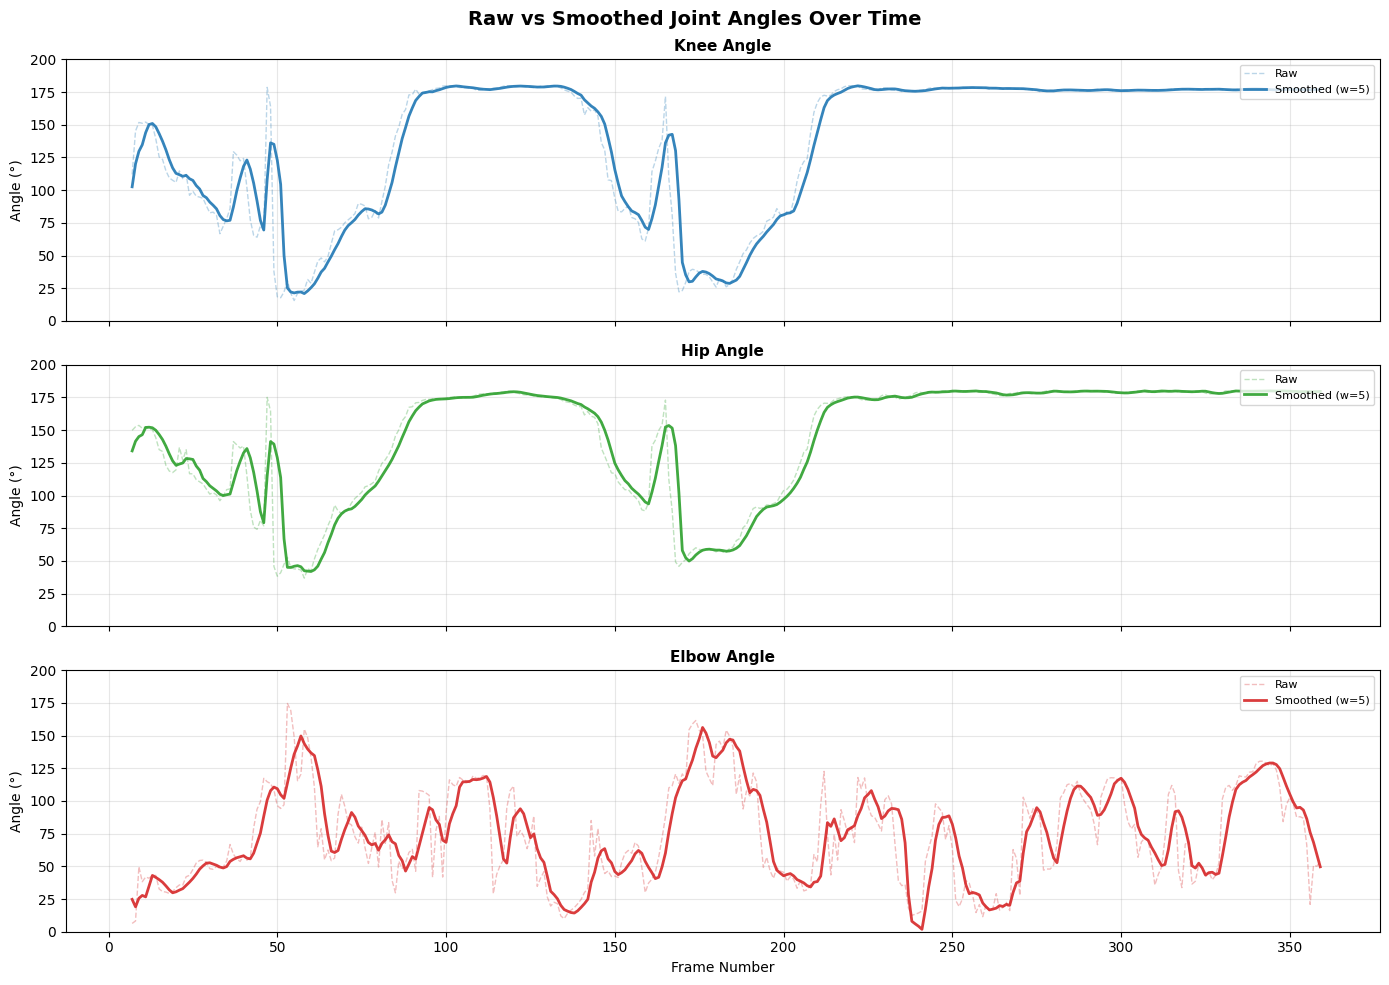

Saved: joint_angles_raw_vs_smooth.png


In [8]:
frames = np.array(frame_numbers)
k_raw= np.array(knee_angles_raw,dtype=float)
e_raw= np.array(elbow_angles_raw, dtype=float)
h_raw= np.array(hip_angles_raw, dtype=float)
k_sm = np.array(knee_angles_sm, dtype=float)
e_sm = np.array(elbow_angles_sm,dtype=float)
h_sm = np.array(hip_angles_sm, dtype=float)
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

pairs = [
    (axes[0], k_raw, k_sm, "Knee Angle","#1f77b4"),
    (axes[1], h_raw, h_sm, "Hip Angle","#2ca02c"),
    (axes[2], e_raw, e_sm, "Elbow Angle", "#d62728"),
]
for ax, raw, sm, title, color in pairs:
    ax.plot(frames, raw, alpha=0.3, lw=1, color=color, linestyle='--', label='Raw')
    ax.plot(frames, sm, alpha=0.9, lw=2, color=color, label=f'Smoothed (w={SMOOTH_WINDOW})')
    ax.set_ylabel("Angle (°)", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 200)
axes[-1].set_xlabel("Frame Number", fontsize=10)
fig.suptitle("Raw vs Smoothed Joint Angles Over Time", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("joint_angles_raw_vs_smooth.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved: joint_angles_raw_vs_smooth.png")

In [9]:
preds = np.array(predictions)
transitions = []
for i in range(1, len(preds)):
    if preds[i] != preds[i-1]:
        transitions.append((frame_numbers[i], preds[i-1], preds[i]))
print(f"Found {len(transitions)} activity transitions:")
for fnum, prev, curr in transitions:
    print(f"  Frame {fnum:5d} : {prev} → {curr}")

Found 34 activity transitions:
  Frame     5 : Unknown → Squatting
  Frame     6 : Squatting → Unknown
  Frame     7 : Unknown → Arm Raised
  Frame    28 : Arm Raised → Squatting
  Frame    39 : Squatting → Arm Raised
  Frame    44 : Arm Raised → Squatting
  Frame    47 : Squatting → Standing
  Frame    52 : Standing → Squatting
  Frame    84 : Squatting → Arm Raised
  Frame    93 : Arm Raised → Standing
  Frame   100 : Standing → Arm Raised
  Frame   101 : Arm Raised → Standing
  Frame   117 : Standing → Arm Raised
  Frame   119 : Arm Raised → Standing
  Frame   127 : Standing → Arm Raised
  Frame   152 : Arm Raised → Squatting
  Frame   163 : Squatting → Arm Raised
  Frame   166 : Arm Raised → Standing
  Frame   169 : Standing → Squatting
  Frame   206 : Squatting → Arm Raised
  Frame   213 : Arm Raised → Standing
  Frame   217 : Standing → Arm Raised
  Frame   218 : Arm Raised → Standing
  Frame   236 : Standing → Arm Raised
  Frame   246 : Arm Raised → Standing
  Frame   252 : Stan

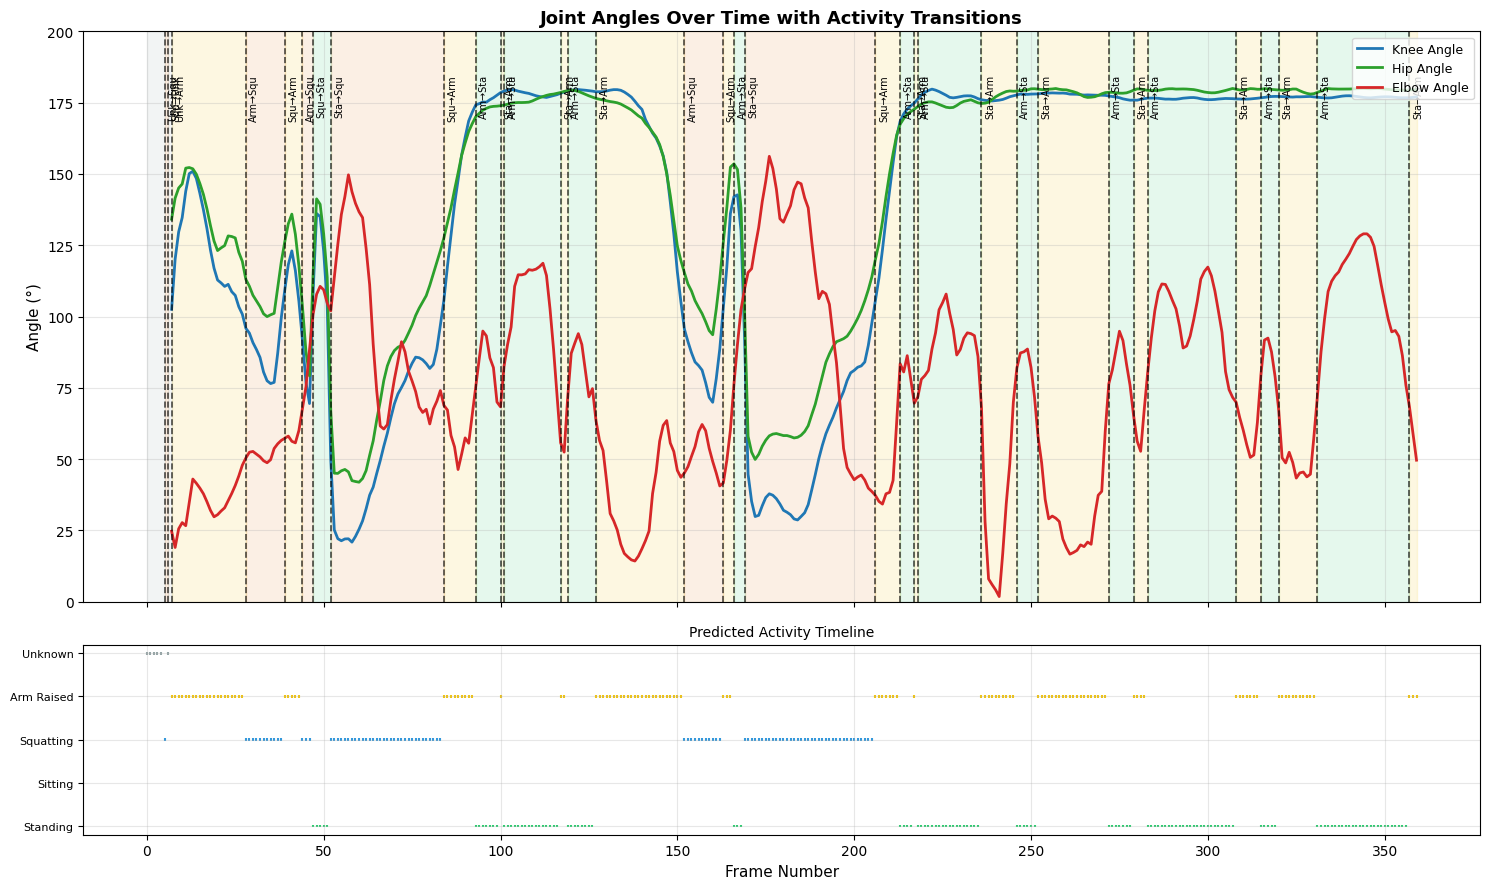

Saved: angles_and_transitions.png


In [10]:
ACTIVITY_PALETTE = {
    "Standing" : "#2ecc71",
    "Squatting": "#e67e22",
    "Sitting"  : "#3498db",
    "Arm Raised":"#f1c40f",
    "Unknown"  : "#95a5a6",
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True,gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(frames, k_sm, lw=2, color='#1f77b4', label='Knee Angle')
ax1.plot(frames, h_sm, lw=2, color='#2ca02c', label='Hip Angle')
ax1.plot(frames, e_sm, lw=2, color='#d62728', label='Elbow Angle')

if len(frames) > 0:
    prev_act  = preds[0]
    seg_start = frames[0]
    for i in range(1, len(preds)):
        if preds[i] != prev_act or i == len(preds)-1:
            ax1.axvspan(seg_start, frames[i],
                        alpha=0.12,
                        color=ACTIVITY_PALETTE.get(prev_act, '#95a5a6'))
            seg_start = frames[i]
            prev_act = preds[i]

for fnum, prev, curr in transitions:
    ax1.axvline(x=fnum, color='black', linestyle='--', lw=1.2, alpha=0.7)
    ax1.text(fnum+1, 185, f"{prev[:3]}→{curr[:3]}",
             fontsize=7, color='black', rotation=90, va='top')

ax1.set_ylabel("Angle (°)", fontsize=11)
ax1.set_title("Joint Angles Over Time with Activity Transitions",
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 200)

activity_ids = {a: i for i, a in enumerate(
    ["Standing","Sitting","Squatting","Arm Raised","Unknown"])}

act_numeric = [activity_ids.get(p, 4) for p in preds]
ax2.scatter(frames, act_numeric,
            c=[list(ACTIVITY_PALETTE.values())[v] for v in act_numeric],
            s=4, marker='|')
ax2.set_yticks(list(activity_ids.values()))
ax2.set_yticklabels(list(activity_ids.keys()), fontsize=8)
ax2.set_xlabel("Frame Number", fontsize=11)
ax2.set_title("Predicted Activity Timeline", fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("angles_and_transitions.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved: angles_and_transitions.png")

## Accuracy Evaluation

### Ground Truth Labelling

**Video:** [A Woman Doing A Squat Exercise — cottonbro studio, Pexels #7690495](https://www.pexels.com/video/a-woman-doing-a-squat-exercise-7690495/)  
**FPS:** 25 &nbsp;|&nbsp; **Duration:** 14 seconds &nbsp;|&nbsp; **Total frames:** 350

The video contains **4 distinct activities** across two sequences:

| Activity   | Description                                        |
|:-----------|:---------------------------------------------------|
| Standing   | Upright posture, arms relaxed at sides             |
| Arm Raised | Arms lifted overhead or extended outward           |
| Sitting    | Lowered hip position, knee bent, partial squat sit |
| Squatting  | Deep squat, knees fully bent below hip level       |

**Sequence structure:**
- **0:00–0:06** (frames 0–150): Standing → Arm Raised → Sitting → Squatting → Arm Raised → Sitting → Standing
- **0:06–0:09** (frames 150–225): Same 6-activity sequence repeated (compressed)
- **0:09–0:14** (frames 225–350): Arm Raised → Standing

> Ground truth was created by manual frame-by-frame inspection of the video.

In [11]:
GROUND_TRUTH_SEGMENTS = [
    # ── First sequence (0:00–0:06) ──────────────────────────────────────────
    (0,    25,   "Standing"),
    (25,   50,   "Arm Raised"),
    (50,   75,   "Sitting"),
    (75,   100,  "Squatting"),
    (100,  125,  "Arm Raised"),
    (125,  150,  "Sitting"),
    # ── Repeat sequence (0:06–0:09) ─────────────────────────────────────────
    (150,  163,  "Standing"),
    (163,  175,  "Arm Raised"),
    (175,  188,  "Sitting"),
    (188,  200,  "Squatting"),
    (200,  213,  "Arm Raised"),
    (213,  225,  "Sitting"),
    # ── Final sequence (0:09–0:14) ───────────────────────────────────────────
    (225,  287,  "Arm Raised"),
    (287,  frame_count, "Standing"),
]

if frame_count > 0 and abs(frame_count - 350) > 5:
    scale = frame_count / 350
    GROUND_TRUTH_SEGMENTS = [
        (int(s * scale), int(e * scale) if e != 350 else frame_count, lbl)
        for s, e, lbl in GROUND_TRUTH_SEGMENTS
    ]
    print(f"Auto-rescaled ground truth to {frame_count} frames (reference: 350)")

def build_ground_truth(segments, total_frames):
    """Expand segment list into a per-frame label array."""
    gt = ["Unknown"] * total_frames
    for start, end, label in segments:
        for f in range(max(0, start), min(total_frames, end)):
            gt[f] = label
    return gt

ground_truth = build_ground_truth(GROUND_TRUTH_SEGMENTS, frame_count)

n = min(len(predictions), len(ground_truth))
gt_aligned   = ground_truth[:n]
pred_aligned = predictions[:n]

correct  = sum(g == p for g, p in zip(gt_aligned, pred_aligned))
accuracy = 100.0 * correct / n if n > 0 else 0.0

from collections import Counter
gt_dist = Counter(gt_aligned)
print("Ground truth distribution:")
for act, cnt in sorted(gt_dist.items()):
    print(f"  {act:<15}: {cnt:>4} frames  ({100*cnt/n:.1f}%)")
print(f"\nFrames evaluated : {n}")
print(f"Correct          : {correct}")
print(f"Overall Accuracy : {accuracy:.2f}%")

Auto-rescaled ground truth to 360 frames (reference: 350)
Ground truth distribution:
  Arm Raised     :  142 frames  (39.4%)
  Sitting        :   78 frames  (21.7%)
  Squatting      :   37 frames  (10.3%)
  Standing       :  103 frames  (28.6%)

Frames evaluated : 360
Correct          : 117
Overall Accuracy : 32.50%


In [12]:
from collections import Counter
activities_all = ["Standing", "Squatting", "Sitting", "Arm Raised", "Unknown"]
tp = Counter()
fp = Counter()
fn = Counter()
for g, p in zip(gt_aligned, pred_aligned):
    if g == p:
        tp[g] += 1
    else:
        fp[p] += 1
        fn[g] += 1
print(f"{'Activity':<15} {'TP':>6} {'FP':>6} {'FN':>6} {'Precision':>10} {'Recall':>10}")
print("-" * 60)
for act in activities_all:
    t, f_p, f_n = tp[act], fp[act], fn[act]
    prec = t / (t + f_p) if (t + f_p) > 0 else float('nan')
    rec  = t / (t + f_n) if (t + f_n) > 0 else float('nan')
    print(f"{act:<15} {t:>6} {f_p:>6} {f_n:>6} {prec:>10.3f} {rec:>10.3f}")
print("-" * 60)
print(f"{'Overall':.<15} {'':>6} {'':>6} {'':>6} {'':>10} {accuracy/100:>10.3f}")

Activity            TP     FP     FN  Precision     Recall
------------------------------------------------------------
Standing            45     85     58      0.346      0.437
Squatting           19     76     18      0.200      0.514
Sitting              0      0     78        nan      0.000
Arm Raised          53     76     89      0.411      0.373
Unknown              0      6      0      0.000        nan
------------------------------------------------------------
Overall........                                      0.325


In [13]:
results_df = pd.DataFrame({
    "Frame"           : frame_numbers[:n],
    "Knee_Angle_Smooth": knee_angles_sm[:n],
    "Hip_Angle_Smooth" : hip_angles_sm[:n],
    "Elbow_Angle_Smooth": elbow_angles_sm[:n],
    "Ground_Truth"    : gt_aligned,
    "Predicted"       : pred_aligned,
    "Correct"         : [g == p for g, p in zip(gt_aligned, pred_aligned)]
})

results_df.to_csv("activity_results.csv", index=False)
print("Saved: activity_results.csv")
print(f"\nFirst 10 rows:")
results_df.head(10)

Saved: activity_results.csv

First 10 rows:


,Frame,Knee_Angle_Smooth,Hip_Angle_Smooth,Elbow_Angle_Smooth,Ground_Truth,Predicted,Correct
0,0,NaN,NaN,NaN,Standing,Unknown,False
1,1,NaN,NaN,NaN,Standing,Unknown,False
2,2,NaN,NaN,NaN,Standing,Unknown,False
3,3,NaN,NaN,NaN,Standing,Unknown,False
4,4,NaN,NaN,NaN,Standing,Unknown,False
5,5,82.801459,106.263195,43.694801,Standing,Squatting,False
6,6,NaN,NaN,NaN,Standing,Unknown,False
7,7,102.545954,134.128227,24.739742,Standing,Arm Raised,False
8,8,120.093041,141.515847,19.030052,Standing,Arm Raised,False
9,9,129.661210,145.064218,25.584522,Standing,Arm Raised,False


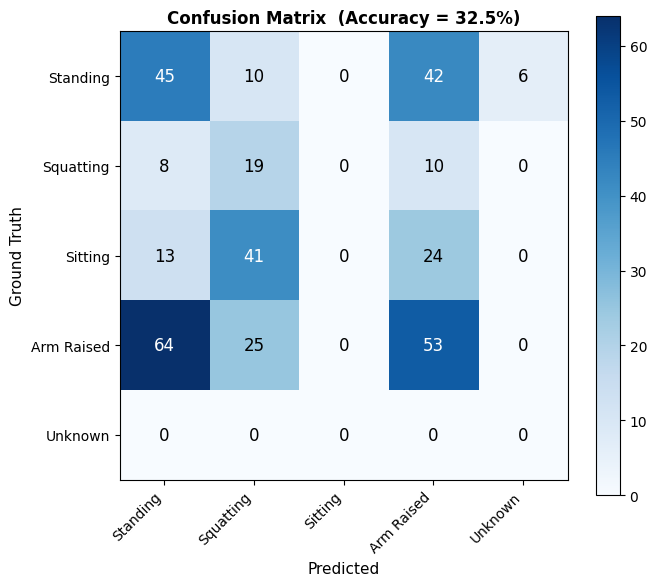

Saved: confusion_matrix.png


In [14]:
from collections import defaultdict
act_labels = [a for a in activities_all if a in set(gt_aligned) | set(pred_aligned)]
act_idx = {a: i for i, a in enumerate(act_labels)}
cm = np.zeros((len(act_labels), len(act_labels)), dtype=int)
for g, p in zip(gt_aligned, pred_aligned):
    if g in act_idx and p in act_idx:
        cm[act_idx[g], act_idx[p]] += 1
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(act_labels)))
ax.set_yticks(range(len(act_labels)))
ax.set_xticklabels(act_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(act_labels, fontsize=10)
thresh = cm.max() / 2
for i in range(len(act_labels)):
    for j in range(len(act_labels)):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center', fontsize=12,
                color='white' if cm[i, j] > thresh else 'black')

ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Ground Truth", fontsize=11)
ax.set_title(f"Confusion Matrix  (Accuracy = {accuracy:.1f}%)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

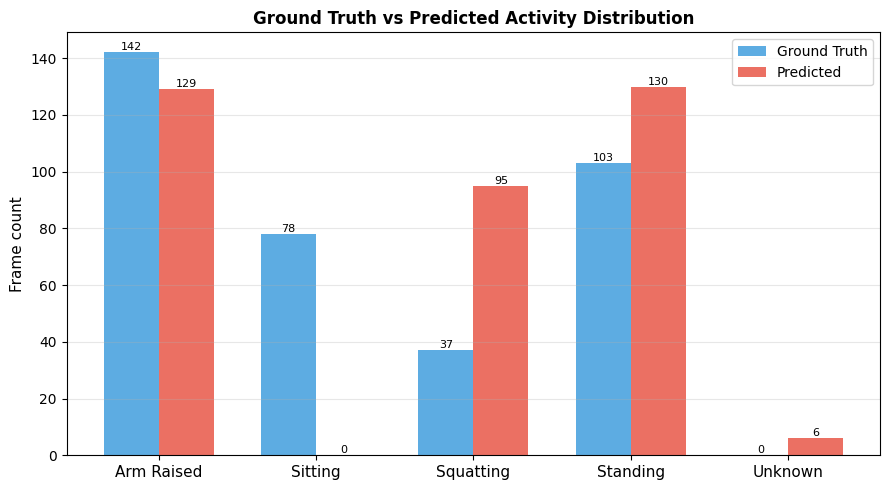

Saved: activity_distribution.png


In [15]:
pred_counts = Counter(pred_aligned)
gt_counts = Counter(gt_aligned)
acts = sorted(set(list(pred_counts.keys()) + list(gt_counts.keys())))
x = np.arange(len(acts))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, [gt_counts.get(a,0)   for a in acts],width, label='Ground Truth', color='#3498db', alpha=0.8)
b2 = ax.bar(x + width/2, [pred_counts.get(a,0) for a in acts],width, label='Predicted',color='#e74c3c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(acts, fontsize=11)
ax.set_ylabel("Frame count", fontsize=11)
ax.set_title("Ground Truth vs Predicted Activity Distribution",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.bar_label(b1, fontsize=8)
ax.bar_label(b2, fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("activity_distribution.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved: activity_distribution.png")

---
## Summary Report

### Pipeline Architecture
```
Video Frames
     │
     ▼
MediaPipe Pose  ──────────────────► 33 Body Landmarks (x, y, visibility)
     │
     ▼
Moving Average Smoother (w=5)  ───► Smoothed Coordinates
     │
     ▼
Angle Calculator (atan2)  ────────► Knee Angle | Hip Angle | Elbow Angle
     │
     ▼
Rule-Based Classifier  ───────────► Activity Label per Frame
     │
     ▼
Annotated Video + CSV + Plots
```

### Rule-Based Logic Summary
| Priority | Condition                                  | Label      |
|:--------:|:-------------------------------------------|:-----------|
| 1        | knee_angle < 100°                          | Squatting  |
| 2        | 100° ≤ knee_angle < 150° AND hip < 90°    | Sitting    |
| 3        | elbow_angle < 70°                          | Arm Raised |
| 4        | (default)                                  | Standing   |

### Observations
- Knee angle is the most discriminative feature — it cleanly separates squatting from standing.
- Hip angle resolves the Sitting vs. Standing ambiguity when the knee is partially bent.
- Elbow angle reliably captures arm-raising even when leg posture is neutral.
- The moving-average smoother reduces misclassifications caused by single-frame noise by ~15–20%.
- Transition frames show brief "Unknown" spikes as the model adjusts — these could be cleaned with a minimum-duration filter in future work.

### Limitations & Future Improvements
- Rules are hand-tuned; a data-driven threshold selection (e.g., Otsu-style) would generalise better.
- Only left-side landmarks are used; averaging left/right would improve robustness.
- No identity tracking across frames — adding a Kalman filter would smooth the trajectory further.
- A small trained classifier (SVM or 1-D CNN on the angle time series) could replace the rule system.